In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib.pyplot import scatter

In [3]:
df = pd.read_csv('tactile.csv').reset_index(drop=True)
df

,tactile_lh_palm_0_0_0,tactile_lh_palm_0_0_1,tactile_lh_palm_0_0_2,tactile_lh_palm_0_0_3,tactile_lh_palm_0_1_0,tactile_lh_palm_0_1_1,tactile_lh_palm_0_1_2,tactile_lh_palm_0_1_3,tactile_lh_palm_1_0_0,tactile_lh_palm_1_0_1,...,tactile_rh_thdistal_1_1_2,tactile_rh_thdistal_1_1_3,tactile_rh_thdistal_2_0_0,tactile_rh_thdistal_2_0_1,tactile_rh_thdistal_2_0_2,tactile_rh_thdistal_2_0_3,tactile_rh_thdistal_2_1_0,tactile_rh_thdistal_2_1_1,tactile_rh_thdistal_2_1_2,tactile_rh_thdistal_2_1_3
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5687,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_with_index = df.reset_index()  # 인덱스를 컬럼으로 추가
df_melted = df_with_index.melt(id_vars=df_with_index.columns[0],  # 인덱스였던 column을 유지
                               var_name='tactile',
                               value_name='value')
# separate the tactile column into two columns: tactile and type
df_melted[['tactile', 'hand', 'type', 'x', 'y', 'z']] = df_melted['tactile'].str.split('_', expand=True)
# drop tactile column
df_melted = df_melted.drop(columns=['tactile'])
# remove the type == palm
df_melted = df_melted[df_melted['type'] != 'palm']
df_melted = df_melted[df_melted['type'] != 'lfmetacarpal']
df_melted = df_melted[df_melted['type'] != 'thproximal']
df_melted = df_melted[df_melted['type'] != 'thmiddle']
df_melted = df_melted[df_melted['type'] != 'thdistal']

df_melted

,index,value,hand,type,x,y,z
136536,0,0.0,lh,ffproximal,0,0,0
136537,1,0.0,lh,ffproximal,0,0,0
136538,2,0.0,lh,ffproximal,0,0,0
136539,3,0.0,lh,ffproximal,0,0,0
136540,4,0.0,lh,ffproximal,0,0,0
...,...,...,...,...,...,...,...
4096075,5684,0.0,rh,lfdistal,2,1,3
4096076,5685,0.0,rh,lfdistal,2,1,3
4096077,5686,0.0,rh,lfdistal,2,1,3
4096078,5687,0.0,rh,lfdistal,2,1,3


In [5]:
grouped = df_melted.groupby(['index', 'type']).agg({'value': 'max'}).reset_index()
grouped

,index,type,value
0,0,ffdistal,1.773683
1,0,ffmiddle,4.079931
2,0,ffproximal,0.000000
3,0,lfdistal,0.000000
4,0,lfmiddle,0.000000
...,...,...,...
68263,5688,mfmiddle,5.937016
68264,5688,mfproximal,0.000000
68265,5688,rfdistal,9.626911
68266,5688,rfmiddle,0.000000


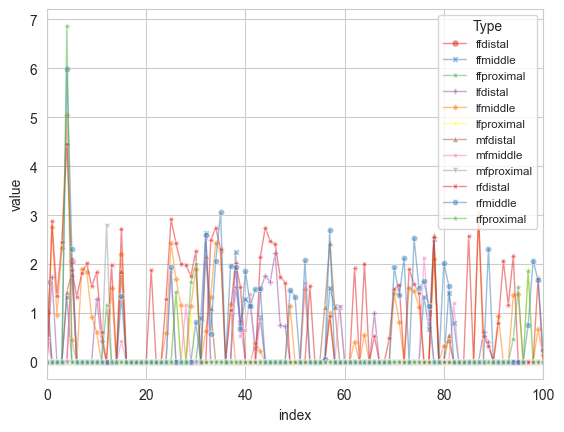

In [6]:
log_scaled = grouped.copy()
log_scaled['value'] = abs(log_scaled['value'])  # log1p는 음수에 대해 정의되지 않으므로 절댓값을 취함
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

log_scaled['value'] = log_scaled['value'].apply(signed_log)

ax = sns.lineplot(data=log_scaled, x='index', y='value', hue='type', markers=True, dashes=False, 
             palette='Set1', style='type', markersize=5, linewidth=1, alpha=0.5)
# set the x lim
ax.set_xlim(0, 100)
# set legend pos
ax.legend(loc='upper right', title='Type', fontsize='small', title_fontsize='medium')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0.5, 0, 'ffdistal'),
  Text(1.5, 0, 'ffmiddle'),
  Text(2.5, 0, 'ffproximal'),
  Text(3.5, 0, 'lfdistal'),
  Text(4.5, 0, 'lfmiddle'),
  Text(5.5, 0, 'lfproximal'),
  Text(6.5, 0, 'mfdistal'),
  Text(7.5, 0, 'mfmiddle'),
  Text(8.5, 0, 'mfproximal'),
  Text(9.5, 0, 'rfdistal'),
  Text(10.5, 0, 'rfmiddle'),
  Text(11.5, 0, 'rfproximal')])

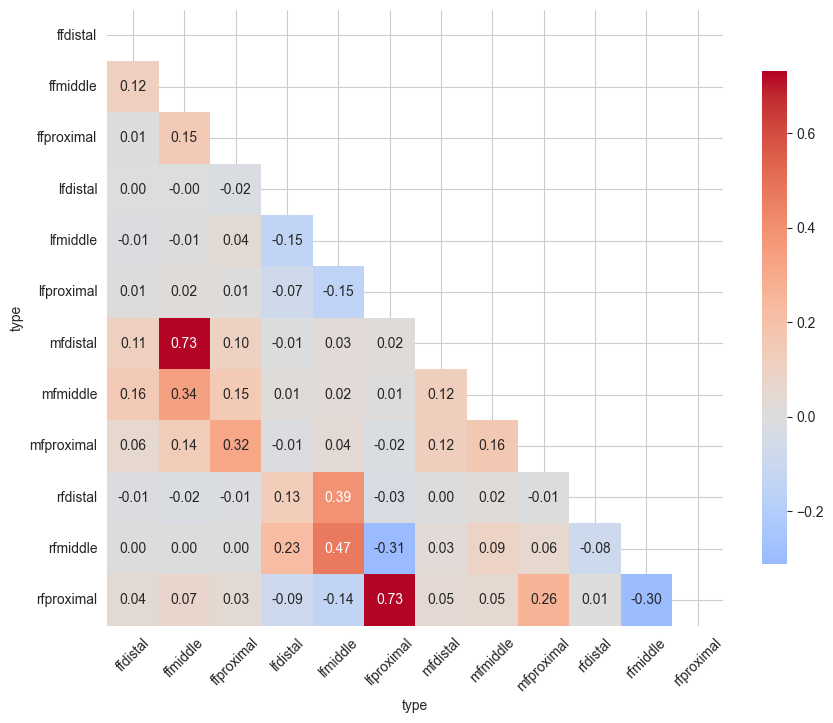

In [7]:
# make correlation matrix for type and value
fig = plt.figure(figsize=(10, 8))
corr_matrix = log_scaled.pivot_table(index='index', columns='type', values='value').corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plot the correlation matrix
# show only the upper triangle of the matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, mask=mask,
            cbar_kws={"shrink": .8}, annot_kws={"size": 10})
# rotate the x labels for 30 degrees
plt.xticks(rotation=45)

/var/folders/x_/2lt9k5kn52q43m1_z0kp7tfm0000gn/T/ipykernel_27700/1043639395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='type', y='value', ax=ax, palette='Set1')


(-2.0, 2.0)

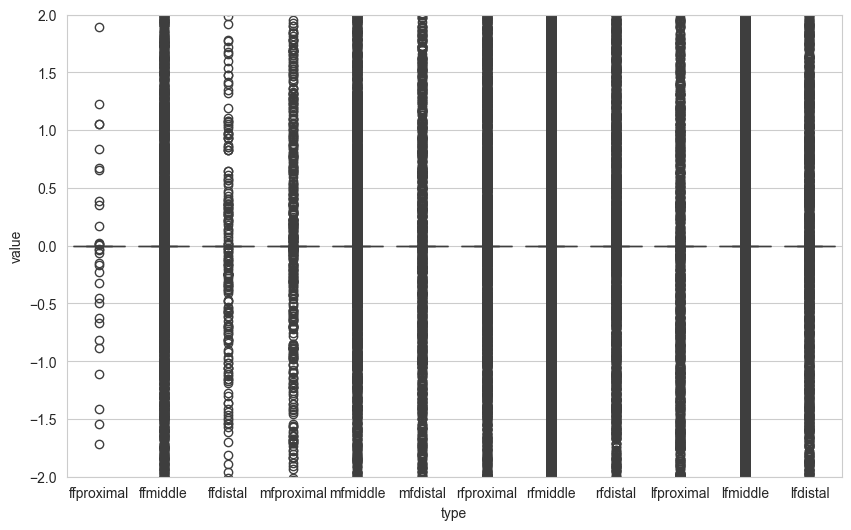

In [8]:
# boxplot for each type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_melted, x='type', y='value', ax=ax, palette='Set1')
# set the y lim
ax.set_ylim(-2, 2)